In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#  STEP 1: LOAD & CLEAN DATA

In [2]:
df = pd.read_csv('Project.csv')

In [3]:
# Standardize Status and Define Target
df['Status'] = df['Status'].astype(str).str.strip().str.upper()
high_potential_list = ['CONVERTED', 'POTENTIAL', 'IN PROGRESS POSITIVE']

In [4]:
# 1 = High Potential, 0 = Low Potential, NaN = Open (to be predicted)
df['Lead_Category'] = df['Status'].apply(lambda x: 1 if x in high_potential_list else (np.nan if x == 'OPEN' else 0))

# STEP 2: EDA (Sales Effectiveness Insights) 

In [5]:
# Conversion Rate by Source
source_effectiveness = df.groupby('Source')['Lead_Category'].mean().sort_values(ascending=False)

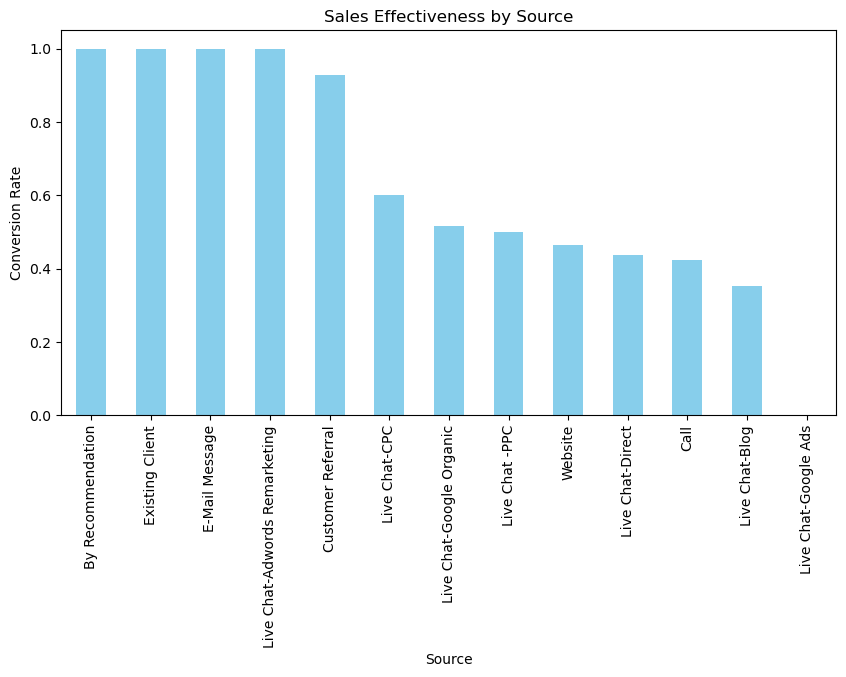

In [6]:
# Conversion Rate by Agent (Top 10)
agent_effectiveness = df.groupby('Sales_Agent')['Lead_Category'].mean().sort_values(ascending=False).head(10)

# Saving EDA Plots
plt.figure(figsize=(10,5))
source_effectiveness.plot(kind='bar', color='skyblue', title='Sales Effectiveness by Source')
plt.ylabel('Conversion Rate')
plt.savefig('source_insights.png')

#  STEP 3: PREPROCESSING & FEATURE ENGINEERING 

In [7]:
# Handle Missing Values
df['Product_ID'] = df['Product_ID'].fillna(-1)
df[['Source', 'Sales_Agent', 'Location']] = df[['Source', 'Sales_Agent', 'Location']].fillna('Unknown')


In [8]:
# Time-based features
df['Created'] = pd.to_datetime(df['Created'], dayfirst=True)
df['Hour'] = df['Created'].dt.hour
df['DayOfWeek'] = df['Created'].dt.dayofweek

In [9]:
# Label Encoding
le = LabelEncoder()
cat_cols = ['Source', 'Sales_Agent', 'Location', 'Delivery_Mode']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# STEP 4: MODEL BUILDING (Gradient Boosting)

In [10]:
# Prepare training set (excluding 'Open' leads)
train_df = df.dropna(subset=['Lead_Category']).copy()
features = cat_cols + ['Product_ID', 'Hour', 'DayOfWeek']
X = train_df[features]
y = train_df['Lead_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model initialization
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42)

#  STEP 5: EVALUATION & PREDICTION 

In [11]:
y_pred = gb_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Predict on the 'Open' leads for the client
open_leads = df[df['Status'] == 'OPEN'].copy()
open_leads['Predicted_Potential'] = gb_model.predict(open_leads[features])
open_leads['Label'] = open_leads['Predicted_Potential'].map({1: 'High Potential', 0: 'Low Potential'})
open_leads.to_csv('FicZon_Lead_Predictions.csv', index=False)

Model Accuracy: 0.7225
              precision    recall  f1-score   support

         0.0       0.76      0.71      0.74       104
         1.0       0.68      0.74      0.71        87

    accuracy                           0.72       191
   macro avg       0.72      0.72      0.72       191
weighted avg       0.73      0.72      0.72       191

